# 1. Importations et Préparation

In [2]:
import os
import glob
from pathlib import Path
from typing import List, Tuple, Dict, Optional, Any

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn import model_selection, metrics
from tqdm import tqdm

# PyTorch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

# Augmentation d'images
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device utilisé : {DEVICE}")
print(f"PyTorch version : {torch.__version__}")

Device utilisé : cpu
PyTorch version : 2.9.1+cpu


# 2. Configuration et Hyperparamètres

In [ ]:
# ============================================
# CHEMINS
# ============================================
DATA_DIR = Path("C:/Users/htalbi/workspace/projet_API/data/captcha_images_v2")

# ============================================
# PARAMÈTRES DU MODÈLE
# ============================================
IMAGE_WIDTH = 300       # Largeur cible
IMAGE_HEIGHT = 75       # Hauteur cible
CAPTCHA_LENGTH = 5      # Nombre de caractères par CAPTCHA

# ============================================
# PARAMÈTRES D'ENTRAÎNEMENT
# ============================================
BATCH_SIZE = 16        
EPOCHS = 100            
LEARNING_RATE = 1e-3    # 0.001 
PATIENCE = 10           # Early stopping : arrêt si pas d'amélioration pendant 10 epochs

# ============================================
# SPLIT DES DONNÉES
# ============================================
TRAIN_RATIO = 0.80      # 80% pour l'entraînement
VAL_RATIO = 0.10        # 10% pour la validation
TEST_RATIO = 0.10       # 10% pour le test final

print(f"Nombre de fichiers : {len(list(DATA_DIR.glob('*.png')))}")

Nombre de fichiers : 1040


# 3. Chargement et Analyse des Données

In [7]:
def load_data(data_dir: Path) -> Tuple[List[str], List[str], List[str]]:
    """
    Liste les chemins des images et extrait les labels des noms de fichiers.
    
    Args:
        data_dir: Chemin vers le dossier contenant les images.
        
    Returns:
        Un triplet (chemins_images, labels, vocabulaire).
    """
    image_paths: List[str] = sorted(glob.glob(str(data_dir / "*.png")))
    labels: List[str] = [Path(x).stem for x in image_paths]
    characters: List[str] = sorted(set("".join(labels)))
    
    return image_paths, labels, characters


# Chargement
image_paths, labels, vocab = load_data(DATA_DIR)


ANALYSE DU DATASET
Nombre d'images : 1040
Vocabulaire (19 caractères) : ['2', '3', '4', '5', '6', '7', '8', 'b', 'c', 'd', 'e', 'f', 'g', 'm', 'n', 'p', 'w', 'x', 'y']
Longueur des CAPTCHAs : {5}

Distribution des caractères :
Caractère  Fréquence  Pourcentage
        2        265         5.10
        3        267         5.13
        4        284         5.46
        5        281         5.40
        6        259         4.98
        7        258         4.96
        8        264         5.08
        b        240         4.62
        c        262         5.04
        d        259         4.98
        e        235         4.52
        f        271         5.21
        g        271         5.21
        m        275         5.29
        n        525        10.10
        p        253         4.87
        w        235         4.52
        x        264         5.08
        y        232         4.46

Total caractères : 5200
Min fréquence : 232 (y)
Max fréquence : 525 (n)


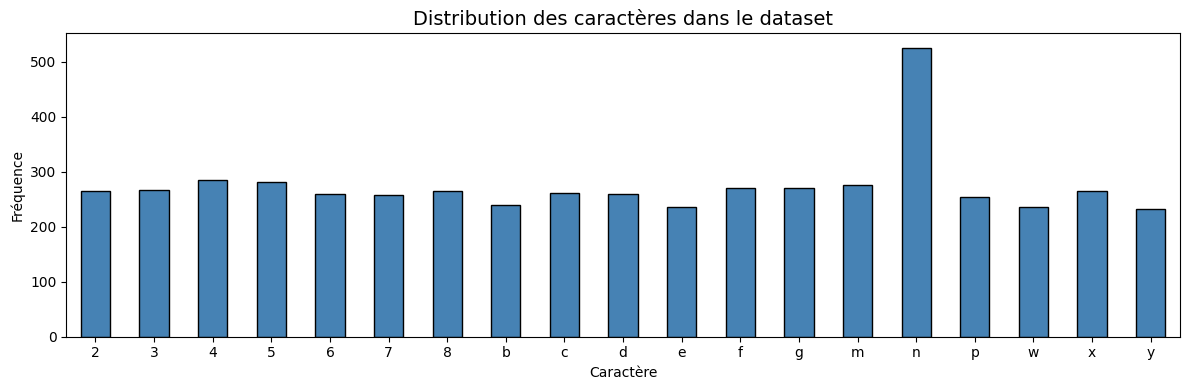

In [15]:
# Analyse du dataset
print("ANALYSE DU DATASET")
print(f"Nombre d'images : {len(image_paths)}")
print(f"Vocabulaire ({len(vocab)} caractères) : {vocab}")
print(f"Longueur des CAPTCHAs : {set(len(l) for l in labels)}")
print()

# Distribution des caractères
all_chars = "".join(labels)
char_counts = pd.Series(list(all_chars)).value_counts().sort_index()

# Affichage en tableau
print("Distribution des caractères :")
distribution_df = pd.DataFrame({
    "Caractère": char_counts.index,
    "Fréquence": char_counts.values,
    "Pourcentage": (char_counts.values / char_counts.sum() * 100).round(2)
})
print(distribution_df.to_string(index=False))
print()
print(f"Total caractères : {char_counts.sum()}")
print(f"Min fréquence : {char_counts.min()} ({char_counts.idxmin()})")
print(f"Max fréquence : {char_counts.max()} ({char_counts.idxmax()})")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 4))
char_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Distribution des caractères dans le dataset", fontsize=14)
ax.set_xlabel("Caractère")
ax.set_ylabel("Fréquence")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Encodage des Labels (Caractère ↔ Nombre)

In [8]:
from torch.utils.data import Dataset


class CaptchaDataset(Dataset):
    """
    Dataset personnalisé pour charger les images de CAPTCHA et leurs labels encodés.
    """
    def __init__(
        self, 
        image_paths: List[str], 
        targets: List[List[int]], 
        resize: Tuple[int, int]
    ) -> None:
        """
        Initialise le dataset avec les chemins, les cibles et la taille cible.
        """
        self.image_paths = image_paths
        self.targets = targets
        self.resize = resize # (Hauteur, Largeur)
        
        # Normalisation standard ImageNet
        self.aug = albumentations.Compose([
            albumentations.Normalize(
                mean=(0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225), 
                always_apply=True
            )
        ])

    def __len__(self) -> int:
        """Retourne le nombre total d'exemples."""
        return len(self.image_paths)

    def __getitem__(self, item: int) -> Dict[str, torch.Tensor]:
        """
        Récupère un échantillon (image + label) par son index.
        """
        # Chargement et conversion RGB
        image = Image.open(self.image_paths[item]).convert("RGB")
        
        # Redimensionnement
        image = image.resize((self.resize[1], self.resize[0]), resample=Image.BILINEAR)
        image = np.array(image)
        
        # Augmentation/Normalisation
        augmented = self.aug(image=image)
        image = augmented["image"]
        
        # Conversion format PyTorch (H, W, C) -> (C, H, W)
        image = np.transpose(image, (2, 0, 1)).astype(np.float32)
        
        return {
            "images": torch.tensor(image, dtype=torch.float),
            "targets": torch.tensor(self.targets[item], dtype=torch.long),
        }

In [20]:
# Création des dictionnaires de mapping
# Index 0 réservé pour le "blank" (CTC loss)
char_to_num: Dict[str, int] = {char: idx + 1 for idx, char in enumerate(vocab)}
num_to_char: Dict[int, str] = {idx: char for char, idx in char_to_num.items()}

def encode_label(label: str) -> List[int]:
    """
    Transforme une chaîne de caractères en liste d'entiers.
    
    Args:
        label: Le texte du CAPTCHA (ex: "2n5bb").
    
    Returns:
        Liste d'indices (ex: [1, 15, 4, 8, 8]).
    """
    return [char_to_num[c] for c in label]


def decode_label(encoded: List[int]) -> str:
    """
    Transforme une liste d'entiers en chaîne de caractères.
    
    Args:
        encoded: Liste d'indices.
    
    Returns:
        Le texte décodé.
    """
    return "".join([num_to_char[idx] for idx in encoded if idx != 0])


# Encodage de tous les labels
targets: List[List[int]] = [encode_label(label) for label in labels]

# Affichage du mapping
print("Dictionnaire de traduction :")
print("-" * 30)
mapping_df = pd.DataFrame({
    "Caractère": list(char_to_num.keys()),
    "Index": list(char_to_num.values())
})
print(mapping_df.to_string(index=False))
print("-" * 30)
print(f"Index 0 = 'blank' (caractère vide pour CTC)")
print()

# Test de l'encodage/décodage
test_label = labels[0]
test_encoded = encode_label(test_label)
test_decoded = decode_label(test_encoded)
print(f"Test : '{test_label}' → {test_encoded} → '{test_decoded}'")

Dictionnaire de traduction :
------------------------------
Caractère  Index
        2      1
        3      2
        4      3
        5      4
        6      5
        7      6
        8      7
        b      8
        c      9
        d     10
        e     11
        f     12
        g     13
        m     14
        n     15
        p     16
        w     17
        x     18
        y     19
------------------------------
Index 0 = 'blank' (caractère vide pour CTC)

Test : '226md' → [1, 1, 5, 14, 10] → '226md'


# 5. Dataset PyTorch avec Data Augmentation

In [21]:
class CaptchaDataset(Dataset):
    """
    Dataset personnalisé pour charger les images de CAPTCHA.
    Supporte la data augmentation pour l'entraînement.
    """
    def __init__(
        self, 
        image_paths: List[str], 
        targets: List[List[int]], 
        resize: Tuple[int, int],
        augment: bool = False
    ) -> None:
        """
        Args:
            image_paths: Liste des chemins vers les images.
            targets: Liste des labels encodés.
            resize: Tuple (hauteur, largeur) pour le redimensionnement.
            augment: Si True, applique la data augmentation (pour train uniquement).
        """
        self.image_paths = image_paths
        self.targets = targets
        self.resize = resize
        self.augment = augment
        
        # Augmentation pour l'entraînement
        self.train_transform = A.Compose([
            A.Rotate(limit=5, p=0.5),                          # Rotation légère ±5°
            A.GaussNoise(std_range=(0.02, 0.05), p=0.3),                    # Bruit gaussien
            A.GaussianBlur(blur_limit=(3, 3), p=0.2),         # Flou léger
            A.RandomBrightnessContrast(                        # Variations luminosité/contraste
                brightness_limit=0.2, 
                contrast_limit=0.2, 
                p=0.3
            ),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])
        
        # Transformation simple pour validation/test (pas d'augmentation)
        self.val_transform = A.Compose([
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, item: int) -> Dict[str, torch.Tensor]:
        # Chargement et conversion RGB
        image = Image.open(self.image_paths[item]).convert("RGB")
        
        # Redimensionnement
        image = image.resize((self.resize[1], self.resize[0]), resample=Image.BILINEAR)
        image = np.array(image)
        
        # Choix de la transformation
        transform = self.train_transform if self.augment else self.val_transform
        transformed = transform(image=image)
        image = transformed["image"]
        
        return {
            "images": image,
            "targets": torch.tensor(self.targets[item], dtype=torch.long),
        }



In [24]:
# Test du dataset
test_dataset = CaptchaDataset(
    image_paths=image_paths[:5],
    targets=targets[:5],
    resize=(IMAGE_HEIGHT, IMAGE_WIDTH),
    augment=True
)

print(f"Dataset créé avec {len(test_dataset)} images")
sample = test_dataset[0]
print(f"Shape image : {sample['images'].shape}")
print(f"Shape target : {sample['targets'].shape}")
print(f"Target : {sample['targets'].tolist()} → '{decode_label(sample['targets'].tolist())}'")


Dataset créé avec 5 images
Shape image : torch.Size([3, 75, 300])
Shape target : torch.Size([5])
Target : [1, 1, 5, 14, 10] → '226md'


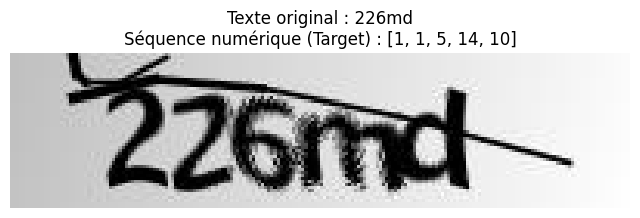

In [26]:
def show_sample(image_path: str, target: List[int]) -> None:
    """
    Affiche une image CAPTCHA avec son texte original et son encodage.
    
    Args:
        image_path: Chemin vers l'image.
        target: Label encodé.
    """
    image = Image.open(image_path).convert("RGB")
    label = Path(image_path).stem
    
    plt.figure(figsize=(8, 4))
    plt.imshow(image)
    plt.title(f"Texte original : {label}\nSéquence numérique (Target) : {target}")
    plt.axis("off")
    plt.show()


# Afficher un exemple
show_sample(image_paths[0], targets[0])

# 6. Visualisation des Augmentations

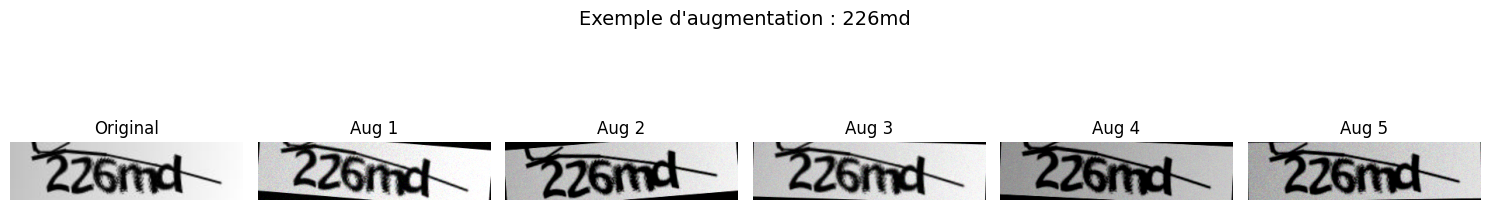

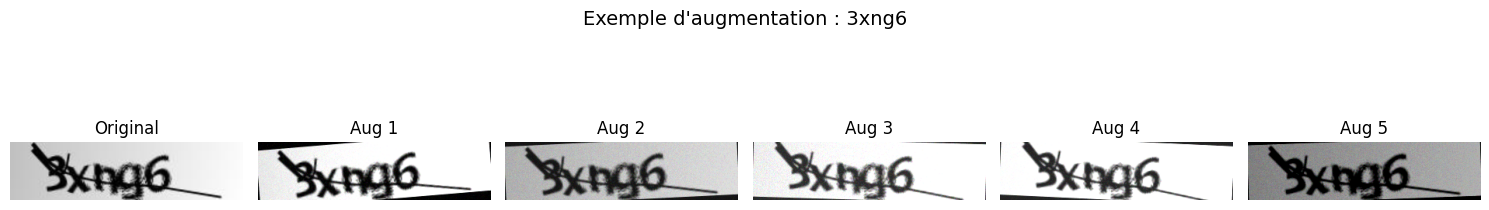

In [25]:
def show_augmentation_examples(image_path: str, n_examples: int = 5) -> None:
    """
    Affiche une image originale et plusieurs versions augmentées.
    
    Args:
        image_path: Chemin vers l'image.
        n_examples: Nombre de versions augmentées à afficher.
    """
    # Chargement de l'image originale
    image = Image.open(image_path).convert("RGB")
    image = image.resize((IMAGE_WIDTH, IMAGE_HEIGHT), resample=Image.BILINEAR)
    image_array = np.array(image)
    
    # Transformation d'augmentation (sans normalisation pour l'affichage)
    aug_transform = A.Compose([
        A.Rotate(limit=5, p=1.0),
        A.GaussNoise(std_range=(0.02, 0.05), p=1.0),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
    ])
    
    # Affichage
    fig, axes = plt.subplots(1, n_examples + 1, figsize=(15, 3))
    
    # Image originale
    axes[0].imshow(image_array)
    axes[0].set_title("Original")
    axes[0].axis("off")
    
    # Versions augmentées
    for i in range(n_examples):
        augmented = aug_transform(image=image_array)["image"]
        axes[i + 1].imshow(augmented)
        axes[i + 1].set_title(f"Aug {i + 1}")
        axes[i + 1].axis("off")
    
    plt.suptitle(f"Exemple d'augmentation : {Path(image_path).stem}", fontsize=14)
    plt.tight_layout()
    plt.show()


# Afficher des exemples
show_augmentation_examples(image_paths[0])
show_augmentation_examples(image_paths[100])

# 7. Split des Données (Train / Validation / Test)

In [27]:
# Premier split : séparer Test (10%) du reste (90%)
train_val_paths, test_paths, train_val_targets, test_targets = model_selection.train_test_split(
    image_paths, 
    targets, 
    test_size=TEST_RATIO, 
    random_state=SEED
)

# Deuxième split : séparer Train (80%) et Validation (10%) à partir des 90% restants
# Note : 0.10 / 0.90 ≈ 0.111 pour obtenir 10% du total
val_size_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

train_paths, val_paths, train_targets, val_targets = model_selection.train_test_split(
    train_val_paths, 
    train_val_targets, 
    test_size=val_size_adjusted, 
    random_state=SEED
)

# Affichage du résumé
print("=" * 50)
print("SPLIT DES DONNÉES")
print("=" * 50)

split_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test", "Total"],
    "Images": [len(train_paths), len(val_paths), len(test_paths), len(image_paths)],
    "Pourcentage": [
        f"{len(train_paths)/len(image_paths)*100:.1f}%",
        f"{len(val_paths)/len(image_paths)*100:.1f}%",
        f"{len(test_paths)/len(image_paths)*100:.1f}%",
        "100%"
    ]
})
print(split_df.to_string(index=False))

SPLIT DES DONNÉES
   Dataset  Images Pourcentage
     Train     831       79.9%
Validation     105       10.1%
      Test     104       10.0%
     Total    1040        100%


# 8. Création des DataLoaders

In [30]:
# Création des datasets
train_dataset = CaptchaDataset(
    image_paths=train_paths,
    targets=train_targets,
    resize=(IMAGE_HEIGHT, IMAGE_WIDTH),
    augment=True  # Augmentation activée pour le train
)

val_dataset = CaptchaDataset(
    image_paths=val_paths,
    targets=val_targets,
    resize=(IMAGE_HEIGHT, IMAGE_WIDTH),
    augment=False  # Pas d'augmentation pour la validation
)

test_dataset = CaptchaDataset(
    image_paths=test_paths,
    targets=test_targets,
    resize=(IMAGE_HEIGHT, IMAGE_WIDTH),
    augment=False  # Pas d'augmentation pour le test
)

# Création des DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Résumé
print("=" * 50)
print(" DATALOADERS CRÉÉS")
print("=" * 50)

loader_df = pd.DataFrame({
    "DataLoader": ["Train", "Validation", "Test"],
    "Images": [len(train_dataset), len(val_dataset), len(test_dataset)],
    "Batches": [len(train_loader), len(val_loader), len(test_loader)],
    "Batch Size": [BATCH_SIZE, BATCH_SIZE, BATCH_SIZE],
    "Augmentation": ["Oui", "Non", "Non"]
})
print(loader_df.to_string(index=False))

 DATALOADERS CRÉÉS
DataLoader  Images  Batches  Batch Size Augmentation
     Train     831       52          16          Oui
Validation     105        7          16          Non
      Test     104        7          16          Non


# 9. Architecture du Modèle CRNN 

In [32]:
class CaptchaModel(nn.Module):
    """
    Modèle CRNN pour la reconnaissance de CAPTCHAs.
    """
    def __init__(self, num_chars: int) -> None:
        """
        Args:
            num_chars: Nombre de caractères uniques dans le vocabulaire.
        """
        super().__init__()
        
        # ============================================
        # 1. EXTRACTION DE CARACTÉRISTIQUES (CNN)
        # ============================================
        
        # Bloc 1 : Détection des formes basiques (contours, lignes)
        self.conv_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn_1 = nn.BatchNorm2d(64)
        self.pool_1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bloc 2 : Détection des formes intermédiaires
        self.conv_2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn_2 = nn.BatchNorm2d(128)
        self.pool_2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bloc 3 : Détection des formes complexes (caractères)
        self.conv_3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn_3 = nn.BatchNorm2d(256)
        self.pool_3 = nn.MaxPool2d(kernel_size=(2, 1))  # Réduit hauteur, garde largeur
        
        # Bloc 4 : Raffinement des features
        self.conv_4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn_4 = nn.BatchNorm2d(256)
        self.pool_4 = nn.MaxPool2d(kernel_size=(2, 1))  # Réduit hauteur, garde largeur
        
        # ============================================
        # 2. SÉQUENCE TEMPORELLE (RNN)
        # ============================================
        
        # Calcul dynamique de la taille après les convolutions
        # Input: (75, 300) → après pools: (4, 75) → flatten: 4 * 256 = 1024
        self.rnn_input_size = 256 * 4  # hauteur_finale * nb_filtres
        
        self.linear_1 = nn.Linear(self.rnn_input_size, 256)
        self.dropout_1 = nn.Dropout(0.3)
        
        # GRU bidirectionnel (lit gauche→droite ET droite→gauche)
        self.lstm = nn.GRU(
            input_size=256,
            hidden_size=128,
            num_layers=2,
            bidirectional=True,
            dropout=0.3,
            batch_first=True
        )
        
        # ============================================
        # 3. CLASSIFICATION
        # ============================================
        
        # 128 * 2 car bidirectionnel (forward + backward)
        self.output = nn.Linear(128 * 2, num_chars + 1)  # +1 pour le blank CTC

    def forward(
        self, 
        images: torch.Tensor, 
        targets: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Forward pass du modèle.
        
        Args:
            images: Batch d'images (B, 3, H, W).
            targets: Labels encodés (optionnel, pour calcul de la loss).
            
        Returns:
            Prédictions et loss (si targets fournis).
        """
        bs = images.size(0)
        device = images.device
        
        # CNN : extraction des features
        x = F.relu(self.bn_1(self.conv_1(images)))
        x = self.pool_1(x)  # (B, 64, 37, 150)
        
        x = F.relu(self.bn_2(self.conv_2(x)))
        x = self.pool_2(x)  # (B, 128, 18, 75)
        
        x = F.relu(self.bn_3(self.conv_3(x)))
        x = self.pool_3(x)  # (B, 256, 9, 75)
        
        x = F.relu(self.bn_4(self.conv_4(x)))
        x = self.pool_4(x)  # (B, 256, 4, 75)
        
        # Reshape pour le RNN : (B, W, C*H) → chaque colonne = un timestep
        x = x.permute(0, 3, 1, 2)  # (B, 75, 256, 4)
        x = x.reshape(bs, x.size(1), -1)  # (B, 75, 1024)
        
        # Projection linéaire
        x = F.relu(self.linear_1(x))
        x = self.dropout_1(x)
        
        # RNN
        x, _ = self.lstm(x)  # (B, 75, 256)
        
        # Classification
        x = self.output(x)  # (B, 75, num_chars + 1)
        
        # Format CTC : (T, B, C)
        x = x.permute(1, 0, 2)  # (75, B, num_chars + 1)
        
        if targets is not None:
            log_probs = F.log_softmax(x, dim=2)
            input_lengths = torch.full((bs,), x.size(0), dtype=torch.long, device=device)
            target_lengths = torch.full((bs,), targets.size(1), dtype=torch.long, device=device)
            
            loss = nn.CTCLoss(blank=0, zero_infinity=True)(
                log_probs, targets, input_lengths, target_lengths
            )
            return x, loss
        
        return x, None


# Création du modèle
model = CaptchaModel(num_chars=len(vocab))
model.to(DEVICE)


CaptchaModel(
  (conv_1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn_1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool_1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn_2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool_2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn_3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool_3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  (conv_4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn_4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool_4): MaxPool2d(kernel_size=(2

In [33]:

# Résumé du modèle
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print("🧠 MODÈLE CRNN AMÉLIORÉ")
print("=" * 50)
print(f"📊 Vocabulaire : {len(vocab)} caractères")
print(f"🔢 Paramètres totaux : {total_params:,}")
print(f"🎯 Paramètres entraînables : {trainable_params:,}")
print(f"🖥️  Device : {DEVICE}")


🧠 MODÈLE CRNN AMÉLIORÉ
📊 Vocabulaire : 19 caractères
🔢 Paramètres totaux : 1,822,740
🎯 Paramètres entraînables : 1,822,740
🖥️  Device : cpu


# 10. Fonctions de Décodage CTC

In [34]:
def remove_duplicates(text: str) -> str:
    """
    Supprime les caractères consécutifs identiques (règle CTC).
    Exemple : "aaabbbcc" → "abc"
    """
    if len(text) < 2:
        return text
    
    result = text[0]
    for char in text[1:]:
        if char != result[-1]:
            result += char
    return result


def decode_predictions(preds: torch.Tensor, mapping: Dict[int, str]) -> List[str]:
    """
    Transforme les sorties du modèle en texte lisible.
    
    Args:
        preds: Tensor de prédictions (T, B, C).
        mapping: Dictionnaire {index: caractère}.
    
    Returns:
        Liste des textes décodés.
    """
    # (T, B, C) → (B, T, C)
    preds = preds.permute(1, 0, 2)
    preds = torch.softmax(preds, dim=2)
    preds = torch.argmax(preds, dim=2)
    preds = preds.detach().cpu().numpy()
    
    results: List[str] = []
    
    for batch_idx in range(preds.shape[0]):
        chars: List[str] = []
        for timestep in preds[batch_idx]:
            if timestep == 0:  # Blank CTC
                chars.append("§")  # Marqueur temporaire
            else:
                chars.append(mapping[timestep])
        
        # Nettoyage : supprimer blanks et doublons
        text = "".join(chars).replace("§", "")
        text = remove_duplicates(text)
        results.append(text)
    
    return results


# Test rapide
print("✅ Fonctions de décodage prêtes")

✅ Fonctions de décodage prêtes


# 11. Entraînement avec Early Stopping

In [37]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    learning_rate: float,
    patience: int
) -> Dict[str, List[float]]:
    """
    Entraîne le modèle avec Early Stopping.
    
    Args:
        model: Le modèle à entraîner.
        train_loader: DataLoader d'entraînement.
        val_loader: DataLoader de validation.
        epochs: Nombre maximum d'epochs.
        learning_rate: Taux d'apprentissage initial.
        patience: Nombre d'epochs sans amélioration avant arrêt.
    
    Returns:
        Historique des losses (train et validation).
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    
    # Historique pour les graphiques
    history = {
        "train_loss": [],
        "val_loss": []
    }
    
    # Early Stopping
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    best_model_state = None
    
    print("=" * 60)
    print("🚀 DÉBUT DE L'ENTRAÎNEMENT")
    print("=" * 60)
    
    for epoch in range(epochs):
        # ============================================
        # PHASE D'ENTRAÎNEMENT
        # ============================================
        model.train()
        train_loss = 0.0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in train_pbar:
            images = batch["images"].to(DEVICE)
            targets = batch["targets"].to(DEVICE)
            
            optimizer.zero_grad()
            _, loss = model(images, targets)
            loss.backward()
            
            # Gradient clipping pour éviter l'explosion des gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            
            optimizer.step()
            train_loss += loss.item()
            train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
        avg_train_loss = train_loss / len(train_loader)
        
        # ============================================
        # PHASE DE VALIDATION
        # ============================================
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]")
            for batch in val_pbar:
                images = batch["images"].to(DEVICE)
                targets = batch["targets"].to(DEVICE)
                
                _, loss = model(images, targets)
                val_loss += loss.item()
                val_pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
        avg_val_loss = val_loss / len(val_loader)
        
        # Sauvegarde de l'historique
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        
        # Mise à jour du scheduler
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(avg_val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        # Affichage du résumé
        print(f"\n📊 Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {new_lr:.6f}")
        
        # Afficher si le LR a changé
        if new_lr < old_lr:
            print(f"📉 Learning rate réduit : {old_lr:.6f} → {new_lr:.6f}")
        
        # ============================================
        # EARLY STOPPING
        # ============================================
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
            best_model_state = model.state_dict().copy()
            print(f"✅ Nouveau meilleur modèle sauvegardé (Val Loss: {best_val_loss:.4f})")
        else:
            epochs_without_improvement += 1
            print(f"⚠️ Pas d'amélioration depuis {epochs_without_improvement} epoch(s)")
            
            if epochs_without_improvement >= patience:
                print(f"\n🛑 Early Stopping déclenché après {epoch+1} epochs")
                break
    
    # Restaurer le meilleur modèle
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Meilleur modèle restauré (Val Loss: {best_val_loss:.4f})")
    
    print("=" * 60)
    print("🏁 ENTRAÎNEMENT TERMINÉ")
    print("=" * 60)
    
    return history


# Lancer l'entraînement
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE
)

🚀 DÉBUT DE L'ENTRAÎNEMENT


Epoch 1/100 [Train]:  67%|██████▋   | 35/52 [00:50<00:24,  1.44s/it, loss=3.2726]


KeyboardInterrupt: 

# 12. Visualisation des Courbes d'Entraînement

In [ ]:
def plot_training_history(history: Dict[str, List[float]]) -> None:
    """
    Affiche les courbes de loss (train vs validation).
    
    Args:
        history: Dictionnaire contenant les losses par epoch.
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history["train_loss"], "b-o", label="Train Loss", markersize=4)
    plt.plot(epochs, history["val_loss"], "r-o", label="Validation Loss", markersize=4)
    
    # Marquer le meilleur epoch
    best_epoch = np.argmin(history["val_loss"]) + 1
    best_val_loss = min(history["val_loss"])
    plt.axvline(x=best_epoch, color="green", linestyle="--", label=f"Meilleur epoch ({best_epoch})")
    
    plt.title("Courbes d'Entraînement", fontsize=14)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (CTC)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Résumé
    print(f"📊 Meilleur epoch : {best_epoch}")
    print(f"📉 Meilleure Val Loss : {best_val_loss:.4f}")
    print(f"📈 Train Loss finale : {history['train_loss'][-1]:.4f}")


# Afficher les courbes (après entraînement)
# plot_training_history(history)
print("✅ Fonction plot_training_history prête (à exécuter après entraînement)")

# 13. Métriques d'Évaluation (Accuracy & CER)

In [ ]:
def edit_distance(s1: str, s2: str) -> int:
    """
    Calcule la distance de Levenshtein entre deux chaînes.
    (Nombre minimum d'opérations pour transformer s1 en s2)
    """
    if len(s1) < len(s2):
        return edit_distance(s2, s1)
    
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]


def evaluate_model(
    model: nn.Module, 
    loader: DataLoader, 
    mapping: Dict[int, str]
) -> Tuple[float, float, List[str], List[str]]:
    """
    Évalue le modèle et calcule les métriques.
    
    Args:
        model: Le modèle entraîné.
        loader: DataLoader à évaluer.
        mapping: Dictionnaire {index: caractère}.
    
    Returns:
        Tuple (accuracy, cer, prédictions, labels réels).
    """
    model.eval()
    
    all_preds: List[str] = []
    all_targets: List[str] = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Évaluation"):
            images = batch["images"].to(DEVICE)
            targets = batch["targets"]
            
            preds, _ = model(images)
            decoded_preds = decode_predictions(preds, mapping)
            all_preds.extend(decoded_preds)
            
            # Décoder les targets
            for t in targets:
                target_text = "".join([mapping[idx.item()] for idx in t if idx.item() != 0])
                all_targets.append(target_text)
    
    # Calcul de l'Accuracy (mots parfaitement corrects)
    correct = sum(p == t for p, t in zip(all_preds, all_targets))
    accuracy = correct / len(all_targets) * 100
    
    # Calcul du CER (Character Error Rate)
    total_cer = sum(edit_distance(p, t) for p, t in zip(all_preds, all_targets))
    total_chars = sum(len(t) for t in all_targets)
    cer = total_cer / total_chars * 100
    
    return accuracy, cer, all_preds, all_targets


# Fonction d'affichage des résultats
def print_evaluation_results(accuracy: float, cer: float, dataset_name: str) -> None:
    """Affiche les résultats d'évaluation."""
    print("=" * 50)
    print(f"📊 RÉSULTATS SUR {dataset_name.upper()}")
    print("=" * 50)
    print(f"🎯 Accuracy (mots parfaits) : {accuracy:.2f}%")
    print(f"📏 CER (taux d'erreur caractères) : {cer:.2f}%")
    print("=" * 50)


# À exécuter après l'entraînement :
# accuracy, cer, preds, targets = evaluate_model(model, test_loader, num_to_char)
# print_evaluation_results(accuracy, cer, "Test")
print("✅ Fonctions d'évaluation prêtes (à exécuter après entraînement)")

# 14. Visualisation des Erreurs

In [ ]:
def visualize_predictions(
    model: nn.Module,
    loader: DataLoader,
    mapping: Dict[int, str],
    n_samples: int = 10
) -> None:
    """
    Affiche des exemples de prédictions (correctes et incorrectes).
    
    Args:
        model: Le modèle entraîné.
        loader: DataLoader à visualiser.
        mapping: Dictionnaire {index: caractère}.
        n_samples: Nombre d'exemples à afficher.
    """
    model.eval()
    
    samples = []
    
    with torch.no_grad():
        for batch in loader:
            images = batch["images"].to(DEVICE)
            targets = batch["targets"]
            
            preds, _ = model(images)
            decoded_preds = decode_predictions(preds, mapping)
            
            for i in range(images.size(0)):
                target_text = "".join([mapping[idx.item()] for idx in targets[i] if idx.item() != 0])
                pred_text = decoded_preds[i]
                is_correct = pred_text == target_text
                
                samples.append({
                    "image": images[i].cpu(),
                    "target": target_text,
                    "pred": pred_text,
                    "correct": is_correct
                })
            
            if len(samples) >= n_samples:
                break
    
    # Affichage
    fig, axes = plt.subplots(n_samples, 1, figsize=(10, 2 * n_samples))
    
    for i, sample in enumerate(samples[:n_samples]):
        img = sample["image"].permute(1, 2, 0).numpy()
        
        # Dé-normalisation pour affichage
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        
        status = "✅" if sample["correct"] else "❌"
        color = "green" if sample["correct"] else "red"
        axes[i].set_title(
            f"{status} Vrai: {sample['target']} | Prédit: {sample['pred']}", 
            fontsize=12, 
            color=color
        )
        axes[i].axis("off")
    
    plt.tight_layout()
    plt.show()


def visualize_worst_errors(
    model: nn.Module,
    loader: DataLoader,
    mapping: Dict[int, str],
    n_errors: int = 5
) -> None:
    """
    Affiche les erreurs les plus graves (plus grande distance d'édition).
    
    Args:
        model: Le modèle entraîné.
        loader: DataLoader à analyser.
        mapping: Dictionnaire {index: caractère}.
        n_errors: Nombre d'erreurs à afficher.
    """
    model.eval()
    
    errors = []
    
    with torch.no_grad():
        for batch in loader:
            images = batch["images"].to(DEVICE)
            targets = batch["targets"]
            
            preds, _ = model(images)
            decoded_preds = decode_predictions(preds, mapping)
            
            for i in range(images.size(0)):
                target_text = "".join([mapping[idx.item()] for idx in targets[i] if idx.item() != 0])
                pred_text = decoded_preds[i]
                distance = edit_distance(target_text, pred_text)
                
                if distance > 0:
                    errors.append({
                        "image": images[i].cpu(),
                        "target": target_text,
                        "pred": pred_text,
                        "distance": distance
                    })
    
    # Trier par distance décroissante
    errors.sort(key=lambda x: x["distance"], reverse=True)
    
    if len(errors) == 0:
        print("🎉 Aucune erreur trouvée !")
        return
    
    # Affichage
    n_display = min(n_errors, len(errors))
    fig, axes = plt.subplots(n_display, 1, figsize=(10, 3 * n_display))
    
    if n_display == 1:
        axes = [axes]
    
    for i, error in enumerate(errors[:n_display]):
        img = error["image"].permute(1, 2, 0).numpy()
        
        # Dé-normalisation
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(
            f"❌ Vrai: {error['target']} | Prédit: {error['pred']} | Distance: {error['distance']}", 
            fontsize=12, 
            color="red"
        )
        axes[i].axis("off")
    
    plt.suptitle("Pires Erreurs du Modèle", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


# À exécuter après l'entraînement :
# visualize_predictions(model, test_loader, num_to_char, n_samples=10)
# visualize_worst_errors(model, test_loader, num_to_char, n_errors=5)
print("✅ Fonctions de visualisation prêtes (à exécuter après entraînement)")

# 15. Matrice de Confusion des Caractères

In [ ]:
def plot_confusion_matrix(
    model: nn.Module,
    loader: DataLoader,
    mapping: Dict[int, str]
) -> None:
    """
    Affiche la matrice de confusion des caractères.
    
    Args:
        model: Le modèle entraîné.
        loader: DataLoader à analyser.
        mapping: Dictionnaire {index: caractère}.
    """
    model.eval()
    
    all_target_chars: List[str] = []
    all_pred_chars: List[str] = []
    
    with torch.no_grad():
        for batch in loader:
            images = batch["images"].to(DEVICE)
            targets = batch["targets"]
            
            preds, _ = model(images)
            decoded_preds = decode_predictions(preds, mapping)
            
            for pred, target in zip(decoded_preds, targets):
                target_text = "".join([mapping[idx.item()] for idx in target if idx.item() != 0])
                
                # Comparer caractère par caractère (si même longueur)
                if len(pred) == len(target_text):
                    all_target_chars.extend(list(target_text))
                    all_pred_chars.extend(list(pred))
    
    if len(all_target_chars) == 0:
        print("⚠️ Pas assez de données pour la matrice de confusion")
        return
    
    # Créer la matrice
    labels = sorted(set(all_target_chars + all_pred_chars))
    cm = metrics.confusion_matrix(all_target_chars, all_pred_chars, labels=labels)
    
    # Affichage
    plt.figure(figsize=(14, 12))
    
    # Normaliser pour voir les pourcentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)  # Remplacer NaN par 0
    
    plt.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    plt.title("Matrice de Confusion des Caractères (normalisée)", fontsize=14)
    plt.colorbar(label="Proportion")
    
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, fontsize=10)
    plt.yticks(tick_marks, labels, fontsize=10)
    
    plt.xlabel("Caractère Prédit", fontsize=12)
    plt.ylabel("Caractère Réel", fontsize=12)
    
    # Ajouter les valeurs dans les cellules
    thresh = cm_normalized.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                plt.text(j, i, f"{cm[i, j]}", 
                        ha="center", va="center",
                        color="white" if cm_normalized[i, j] > thresh else "black",
                        fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Afficher les confusions les plus fréquentes
    print("\n🔍 Confusions les plus fréquentes :")
    print("-" * 40)
    
    confusions = []
    for i, true_char in enumerate(labels):
        for j, pred_char in enumerate(labels):
            if i != j and cm[i, j] > 0:
                confusions.append((true_char, pred_char, cm[i, j]))
    
    confusions.sort(key=lambda x: x[2], reverse=True)
    
    for true_char, pred_char, count in confusions[:10]:
        print(f"  '{true_char}' → '{pred_char}' : {count} fois")


# À exécuter après l'entraînement :
# plot_confusion_matrix(model, test_loader, num_to_char)
print("✅ Fonction matrice de confusion prête (à exécuter après entraînement)")

# 16. Sauvegarde du Modèle et des Métadonnées

In [ ]:
import joblib
from datetime import datetime

def save_model(
    model: nn.Module,
    mapping: Dict[str, Any],
    save_dir: str = ".",
    model_name: str = "captcha_model"
) -> None:
    """
    Sauvegarde le modèle et les métadonnées nécessaires pour l'inférence.
    
    Args:
        model: Le modèle entraîné.
        mapping: Dictionnaires char_to_num et num_to_char.
        save_dir: Dossier de sauvegarde.
        model_name: Nom de base des fichiers.
    """
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)
    
    # 1. Sauvegarde des poids du modèle
    model_path = save_path / f"{model_name}.pth"
    torch.save(model.state_dict(), model_path)
    
    # 2. Sauvegarde des métadonnées
    metadata = {
        "char_to_num": char_to_num,
        "num_to_char": num_to_char,
        "vocab": vocab,
        "image_width": IMAGE_WIDTH,
        "image_height": IMAGE_HEIGHT,
        "num_chars": len(vocab),
        "date_trained": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }
    
    mapping_path = save_path / f"{model_name}_mapping.joblib"
    joblib.dump(metadata, mapping_path)
    
    print("=" * 50)
    print("💾 MODÈLE SAUVEGARDÉ")
    print("=" * 50)
    print(f"📁 Poids du modèle : {model_path}")
    print(f"📁 Métadonnées : {mapping_path}")
    print(f"📊 Vocabulaire : {len(vocab)} caractères")
    print(f"📅 Date : {metadata['date_trained']}")
    print("=" * 50)


# À exécuter après l'entraînement :
# save_model(model, {"char_to_num": char_to_num, "num_to_char": num_to_char}, save_dir="models")
print("✅ Fonction de sauvegarde prête (à exécuter après entraînement)")

# 17. Exécution Complète (Train + Évaluation + Sauvegarde)

In [ ]:
# ============================================================
# 🚀 CELLULE D'EXÉCUTION COMPLÈTE
# ============================================================
# Cette cellule lance tout le pipeline :
# 1. Entraînement avec Early Stopping
# 2. Visualisation des courbes
# 3. Évaluation sur le Test Set
# 4. Visualisation des erreurs
# 5. Sauvegarde du modèle
# ============================================================

# 1. ENTRAÎNEMENT
print("\n" + "="*60)
print("🚀 ÉTAPE 1/5 : ENTRAÎNEMENT")
print("="*60)
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    patience=PATIENCE
)

# 2. COURBES DE LOSS
print("\n" + "="*60)
print("📈 ÉTAPE 2/5 : COURBES D'ENTRAÎNEMENT")
print("="*60)
plot_training_history(history)

# 3. ÉVALUATION
print("\n" + "="*60)
print("📊 ÉTAPE 3/5 : ÉVALUATION SUR LE TEST SET")
print("="*60)
accuracy, cer, preds, targets = evaluate_model(model, test_loader, num_to_char)
print_evaluation_results(accuracy, cer, "Test")

# 4. VISUALISATION DES ERREURS
print("\n" + "="*60)
print("🔍 ÉTAPE 4/5 : ANALYSE DES ERREURS")
print("="*60)
visualize_predictions(model, test_loader, num_to_char, n_samples=10)
visualize_worst_errors(model, test_loader, num_to_char, n_errors=5)
plot_confusion_matrix(model, test_loader, num_to_char)

# 5. SAUVEGARDE
print("\n" + "="*60)
print("💾 ÉTAPE 5/5 : SAUVEGARDE")
print("="*60)
save_model(model, {"char_to_num": char_to_num, "num_to_char": num_to_char}, save_dir=".")

# RÉSUMÉ FINAL
print("\n" + "="*60)
print("🏁 RÉSUMÉ FINAL")
print("="*60)
print(f"🎯 Accuracy : {accuracy:.2f}%")
print(f"📏 CER : {cer:.2f}%")
print(f"📚 Epochs effectués : {len(history['train_loss'])}")
print(f"📉 Meilleure Val Loss : {min(history['val_loss']):.4f}")
print("="*60)
print("✅ Pipeline terminé avec succès !")

# Encodage et Visualisation d'un exemple

In [9]:
# 1. Création du dictionnaire de caractères (Mapping)
# On commence à l'indice 1 pour laisser le 0 au caractère spécial "blank" (vide)
char_to_num: Dict[str, int] = {char: idx + 1 for idx, char in enumerate(vocab)}
num_to_char: Dict[int, str] = {idx: char for char, idx in char_to_num.items()}

def encode_label(label: str, mapping: Dict[str, int]) -> List[int]:
    """
    Transforme une chaîne de caractères en une liste d'entiers.
    
    Args:
        label: Le texte du CAPTCHA (ex: "abc").
        mapping: Le dictionnaire de conversion caractère -> nombre.
    """
    return [mapping[c] for c in label]

# 2. Conversion de tous les labels du projet
targets: List[List[int]] = [encode_label(l, char_to_num) for l in labels]

# 3. Création du dataset d'entraînement
full_dataset = CaptchaDataset(
    image_paths=image_paths,
    targets=targets,
    resize=(IMAGE_HEIGHT, IMAGE_WIDTH)
)

# 4. Fonction pour afficher une image "dé-normalisée"
def show_processed_sample(dataset: CaptchaDataset, index: int) -> None:
    """
    Affiche une image du dataset en inversant la normalisation pour l'œil humain.
    """
    sample: Dict[str, torch.Tensor] = dataset[index]
    img_tensor = sample["images"]
    target_indices = sample["targets"]
    
    # Passage du format PyTorch (C, H, W) au format image (H, W, C)
    img = img_tensor.numpy().transpose(1, 2, 0)
    
    # Inversion de la normalisation ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.title(f"Texte original : {labels[index]}\nSéquence numérique (Target) : {target_indices.tolist()}")
    plt.axis("off")
    plt.show()

C:\Users\htalbi\AppData\Local\Temp\ipykernel_10164\3650636790.py:23: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  albumentations.Normalize(


In [10]:
def print_dictionary_mapping(mapping: Dict[str, int]) -> None:
    """
    Affiche proprement la correspondance entre lettres et chiffres.
    """
    print("Dictionnaire de traduction :")
    # On trie par valeur pour plus de clarté
    for char, value in sorted(mapping.items(), key=lambda item: item[1]):
        print(f"  '{char}'  ----->  {value}")

print_dictionary_mapping(char_to_num)

Dictionnaire de traduction :
  '2'  ----->  1
  '3'  ----->  2
  '4'  ----->  3
  '5'  ----->  4
  '6'  ----->  5
  '7'  ----->  6
  '8'  ----->  7
  'b'  ----->  8
  'c'  ----->  9
  'd'  ----->  10
  'e'  ----->  11
  'f'  ----->  12
  'g'  ----->  13
  'm'  ----->  14
  'n'  ----->  15
  'p'  ----->  16
  'w'  ----->  17
  'x'  ----->  18
  'y'  ----->  19


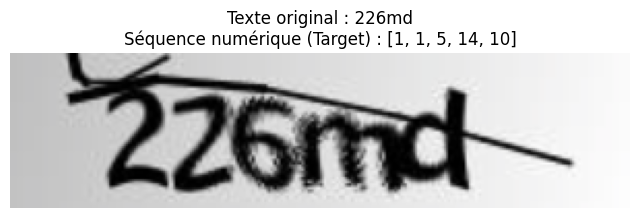

In [11]:
# Test sur le premier exemple
show_processed_sample(full_dataset, 0)

# L'Architecture du Modèle (CNN + RNN)

In [12]:
class CaptchaModel(nn.Module):
    """
    Modèle hybride CRNN (CNN + RNN) pour la reconnaissance de caractères.
    """
    def __init__(self, num_chars: int) -> None:
        """
        Initialise les couches du modèle.
        
        Args:
            num_chars: Nombre de caractères uniques dans le dictionnaire.
        """
        super().__init__()

        # 1. Extraction de caractéristiques (CNN)
        # Bloc 1 : Détecte les formes simples
        self.conv_1: nn.Conv2d = nn.Conv2d(3, 128, kernel_size=(3, 6), padding=(1, 1))
        self.pool_1: nn.MaxPool2d = nn.MaxPool2d(kernel_size=(2, 2))

        # Bloc 2 : Détecte les formes complexes
        self.conv_2: nn.Conv2d = nn.Conv2d(128, 64, kernel_size=(3, 6), padding=(1, 1))
        self.pool_2: nn.MaxPool2d = nn.MaxPool2d(kernel_size=(2, 2))

        # 2. Transition vers le RNN
        # Réduit la dimension avant d'entrer dans la séquence
        self.linear_1: nn.Linear = nn.Linear(1152, 64)
        self.drop_1: nn.Dropout = nn.Dropout(0.2)

        # 3. Analyse de la séquence (RNN)
        # Utilise un GRU bidirectionnel pour lire de gauche à droite ET de droite à gauche
        self.lstm: nn.GRU = nn.GRU(
            input_size=64,
            hidden_size=32,
            bidirectional=True,
            num_layers=2,
            dropout=0.25,
            batch_first=True,
        )

        # 4. Couche de sortie
        # num_chars + 1 pour inclure le caractère spécial "blank"
        self.output: nn.Linear = nn.Linear(64, num_chars + 1)

    def forward(
        self, 
        images: torch.Tensor, 
        targets: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Définit le passage des données dans le réseau.
        
        Args:
            images: Batch d'images de taille (B, 3, H, W).
            targets: Labels encodés (optionnel).
            
        Returns:
            Logits (prédictions brutes) et la perte (loss) si targets est fourni.
        """
        bs: int = images.size(0)

        # Passage dans les convolutions
        x: torch.Tensor = F.relu(self.conv_1(images))
        x = self.pool_1(x)
        x = F.relu(self.conv_2(x))
        x = self.pool_2(x)

        # Préparation pour le RNN : on transforme l'image en séquence
        # On veut que la largeur (W) devienne notre dimension temporelle
        x = x.permute(0, 3, 1, 2)  # (B, C, H, W) -> (B, W, C, H)
        x = x.view(bs, x.size(1), -1) 

        x = F.relu(self.linear_1(x))
        x = self.drop_1(x)

        # Passage dans le GRU
        x, _ = self.lstm(x)

        # Calcul des prédictions finales
        x = self.output(x)
        
        # Formatage pour la perte CTC (Largeur, Batch, Classes)
        x = x.permute(1, 0, 2)

        if targets is not None:
            # On utilise ici la CTC Loss interne
            log_probs = F.log_softmax(x, dim=2)
            input_lengths = torch.full(size=(bs,), fill_value=log_probs.size(0), dtype=torch.int32).to(DEVICE)
            target_lengths = torch.full(size=(bs,), fill_value=targets.size(1), dtype=torch.int32).to(DEVICE)
            loss = nn.CTCLoss(blank=0)(log_probs, targets, input_lengths, target_lengths)
            return x, loss

        return x, None

# Le Traducteur Inverse (Décodage CTC)

In [13]:
def remove_duplicates(text: str) -> str:
    """
    Supprime les caractères consécutifs identiques (règle CTC).
    Exemple : "22266mmd" -> "26md"
    """
    if len(text) < 2:
        return text

    result: str = ""
    for char in text:
        if result == "" or char != result[-1]:
            result += char
    return result

def decode_predictions(preds: torch.Tensor, mapping: Dict[int, str]) -> List[str]:
    """
    Transforme les sorties brutes du modèle en texte lisible.
    """
    # On prend l'indice du caractère ayant le plus haut score
    preds = preds.permute(1, 0, 2) # (T, B, C) -> (B, T, C)
    preds = torch.softmax(preds, 2)
    preds = torch.argmax(preds, 2)
    preds = preds.detach().cpu().numpy()

    final_outputs: List[str] = []

    for b in range(preds.shape[0]):
        temp: List[str] = []
        for k in preds[b, :]:
            k = k - 1 # On enlève le décalage du blank
            if k == -1:
                temp.append("§") # Symbole temporaire pour le blank
            else:
                temp.append(mapping[k + 1]) # On retrouve la lettre

        # On nettoie : on enlève les blanks et on fusionne les doublons
        clean_text = "".join(temp).replace("§", "")
        final_outputs.append(remove_duplicates(clean_text))

    return final_outputs

# L'Entraînement et l'Évaluation

In [14]:
from sklearn import model_selection
from tqdm import tqdm

# 1. Préparation des données et du modèle
train_imgs, test_imgs, train_targets, test_targets = model_selection.train_test_split(
    image_paths, targets, test_size=0.1, random_state=42
)

train_loader = torch.utils.data.DataLoader(
    CaptchaDataset(train_imgs, train_targets, (IMAGE_HEIGHT, IMAGE_WIDTH)),
    batch_size=BATCH_SIZE, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    CaptchaDataset(test_imgs, test_targets, (IMAGE_HEIGHT, IMAGE_WIDTH)),
    batch_size=BATCH_SIZE, shuffle=False
)

model = CaptchaModel(num_chars=len(vocab))
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.8, patience=5)

# 2. La grande boucle d'apprentissage
for epoch in range(EPOCHS):
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train() # Active le dropout
    train_loss = 0.0
    tk0 = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for data in tk0:
        for key, value in data.items():
            data[key] = value.to(DEVICE)
        
        optimizer.zero_grad() # Reset des gradients
        _, loss = model(**data) # Forward pass
        loss.backward() # Calcul des gradients
        optimizer.step() # Mise à jour des poids
        train_loss += loss.item()
        tk0.set_postfix(loss=loss.item())

    # --- PHASE DE VALIDATION ---
    model.eval() # Désactive le dropout
    valid_loss = 0.0
    with torch.no_grad(): # Pas de calcul de gradient pour gagner du temps
        tk1 = tqdm(test_loader, total=len(test_loader), desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]")
        for data in tk1:
            for key, value in data.items():
                data[key] = value.to(DEVICE)
            _, loss = model(**data)
            valid_loss += loss.item()
            tk1.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    avg_valid_loss = valid_loss / len(test_loader)
    
    print(f"Summary -> Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
    scheduler.step(avg_valid_loss) # Ajuste le LR si la perte stagne

C:\Users\htalbi\AppData\Local\Temp\ipykernel_10164\3650636790.py:23: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  albumentations.Normalize(
Epoch 1/50 [Valid]: 100%|██████████| 13/13 [00:02<00:00,  6.18it/s, loss=3.31]


Summary -> Train Loss: 7.7005 | Valid Loss: 3.2930 | LR: 0.000300


Epoch 2/50 [Valid]: 100%|██████████| 13/13 [00:02<00:00,  5.57it/s, loss=3.32]


Summary -> Train Loss: 3.2862 | Valid Loss: 3.2766 | LR: 0.000300


Epoch 3/50 [Valid]: 100%|██████████| 13/13 [00:02<00:00,  6.09it/s, loss=3.33]


...

Summary -> Train Loss: 0.1567 | Valid Loss: 0.1217 | LR: 0.000192


Epoch 49/50 [Valid]: 100%|██████████| 13/13 [00:02<00:00,  6.12it/s, loss=0.0878]


Summary -> Train Loss: 0.1495 | Valid Loss: 0.1221 | LR: 0.000192


Epoch 50/50 [Valid]: 100%|██████████| 13/13 [00:02<00:00,  6.49it/s, loss=0.0954]

Summary -> Train Loss: 0.1377 | Valid Loss: 0.1138 | LR: 0.000192


# Inférence et Visualisation des résultats

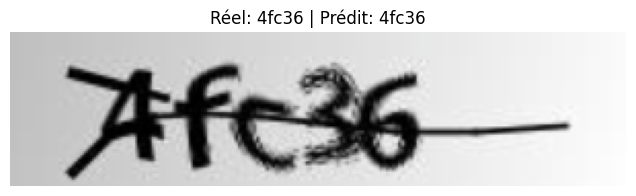

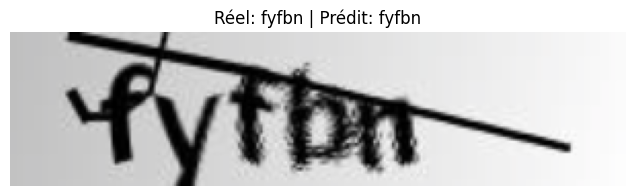

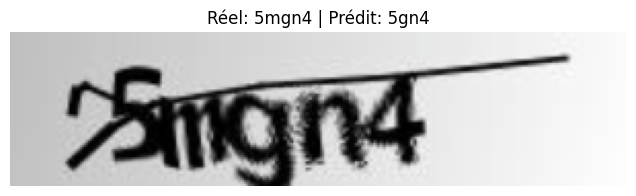

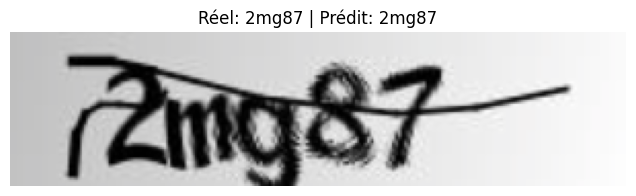

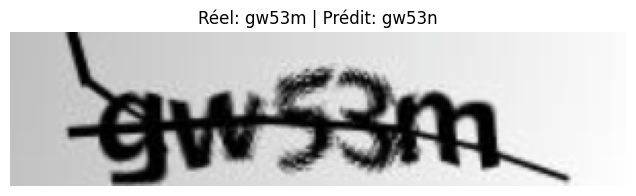

In [15]:
def visualize_predictions(
    model: torch.nn.Module, 
    test_loader: torch.utils.data.DataLoader, 
    mapping: Dict[int, str], 
    num_images: int = 5
) -> None:
    """
    Prend un échantillon d'images du jeu de test, prédit le texte et les affiche.
    
    Args:
        model: Le modèle entraîné.
        test_loader: Le chargeur de données de test.
        mapping: Le dictionnaire pour convertir les chiffres en lettres.
        num_images: Nombre d'images à afficher.
    """
    model.eval() # Désactive le dropout pour la prédiction
    images_shown = 0
    
    # On ne calcule pas les gradients ici (gain de mémoire et vitesse)
    with torch.no_grad():
        for data in test_loader:
            # Envoi des données sur le GPU/CPU
            images = data["images"].to(DEVICE)
            targets = data["targets"]
            
            # Le modèle nous donne les scores (logits)
            batch_preds, _ = model(images)
            
            # On utilise notre logique de décodage
            # Rappel : decode_predictions doit être définie ou importée
            current_preds = decode_predictions(batch_preds, mapping)
            
            # Conversion des targets (réel) en texte lisible pour comparer
            real_texts = []
            for t in targets:
                t_list = t.numpy().tolist()
                # On décode les targets en ignorant le blank (0)
                real_texts.append("".join([mapping[i] for i in t_list if i != 0]))

            # Affichage avec Matplotlib
            for i in range(images.size(0)):
                if images_shown >= num_images:
                    return
                
                img = images[i].cpu().numpy().transpose(1, 2, 0)
                # Inversion de la normalisation pour l'affichage
                mean = [0.485, 0.456, 0.406]
                std = [0.229, 0.224, 0.225]
                img = std * img + mean
                img = img.clip(0, 1)
                
                plt.figure(figsize=(10, 2))
                plt.imshow(img)
                plt.title(f"Réel: {real_texts[i]} | Prédit: {current_preds[i]}")
                plt.axis("off")
                plt.show()
                
                images_shown += 1

# On lance la visualisation sur 5 images du jeu de test
visualize_predictions(model, test_loader, num_to_char, num_images=5)

# Calcul de l'Accuracy globale

In [16]:
def calculate_accuracy(model: torch.nn.Module, loader: torch.utils.data.DataLoader) -> float:
    """
    Calcule le pourcentage de CAPTCHAs parfaitement résolus sur un dataset.
    """
    model.eval() # Mode évaluation
    all_preds: List[str] = []
    all_targets: List[str] = []
    
    with torch.no_grad():
        for data in loader:
            images = data["images"].to(DEVICE)
            targets = data["targets"]
            
            # 1. Obtenir les prédictions du modèle
            batch_preds, _ = model(images)
            
            # 2. Décoder les prédictions en texte
            decoded_preds = decode_predictions(batch_preds, num_to_char)
            all_preds.extend(decoded_preds)
            
            # 3. Décoder les cibles (targets) réelles pour la comparaison
            for t in targets:
                target_indices = t.numpy().tolist()
                # On ignore le blank (0) et on convertit les chiffres en lettres
                real_text = "".join([num_to_char[i] for i in target_indices if i != 0])
                all_targets.append(real_text)
    
    # 4. Calcul du score final (strict : égalité parfaite des chaînes)
    accuracy = metrics.accuracy_score(all_targets, all_preds)
    return accuracy

# Calcul et affichage
final_acc = calculate_accuracy(model, test_loader)
print(f"✅ Accuracy finale sur le jeu de test : {final_acc * 100:.2f}%")

✅ Accuracy finale sur le jeu de test : 65.38%


In [21]:
import numpy as np

def edit_distance(s1, s2):
    """Calcule la distance de Levenshtein entre deux chaînes."""
    if len(s1) < len(s2):
        return edit_distance(s2, s1)

    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]

def calculate_metrics(model, loader, mapping):
    """Calcule l'Accuracy et le CER moyen sur un dataset."""
    model.eval()
    total_cer = 0
    total_chars = 0
    correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad():
        for data in loader:
            # 1. On extrait les données du dictionnaire comme dans ton calculate_accuracy
            images = data["images"].to(DEVICE) 
            targets = data["targets"]
            
            preds, _ = model(images)
            
            # 2. Décodage des prédictions en texte
            decoded_preds = decode_predictions(preds, mapping)
            
            # 3. Conversion des targets (étiquettes réelles) en texte pour comparer
            decoded_targets = []
            for t in targets:
                target_indices = t.numpy().tolist()
                # On ignore l'indice 0 (le caractère "vide" du CTC)
                target_text = "".join([mapping[i] for i in target_indices if i != 0])
                decoded_targets.append(target_text)
            
            # 4. Comparaison un par un
            for p, t in zip(decoded_preds, decoded_targets):
                # Calcul de l'Accuracy (mot exact)
                if p == t:
                    correct_predictions += 1
                
                # Calcul du CER (distance de Levenshtein)
                total_cer += edit_distance(p, t)
                total_chars += len(t)
                total_samples += 1
                
    # Calcul des pourcentages finaux
    accuracy = (correct_predictions / total_samples) * 100 if total_samples > 0 else 0
    avg_cer = (total_cer / total_chars) * 100 if total_chars > 0 else 0
    
    return accuracy, avg_cer

In [22]:
# Utilisation de num_to_char qui est ton dictionnaire {index: caractere}
acc, cer = calculate_metrics(model, test_loader, num_to_char)

print(f"🎯 Accuracy (mots parfaits) : {acc:.2f}%")
print(f"📏 CER (taux d'erreur de caractères) : {cer:.2f}%")

🎯 Accuracy (mots parfaits) : 65.38%
📏 CER (taux d'erreur de caractères) : 7.88%


- L'Accuracy (65,38 %) : C'est ton score "tout ou rien". Environ 2 CAPTCHAs sur 3 sont résolus à la perfection.
- Le CER (7,88 %) : C'est ici que se cache la bonne nouvelle. Comme tes CAPTCHAs font généralement 5 caractères, un CER de 7,88 % signifie qu'en moyenne, le modèle ne fait qu'environ 0,4 erreur par image ($5 \times 0,0788$).
- Ce que cela nous dit :Ton modèle n'est pas "perdu". La plupart du temps, lorsqu'il échoue à obtenir le mot parfait, il n'est qu'à une seule lettre de la vérité 🤏. C'est un excellent signe de stabilité, car cela montre que le modèle a bien appris la structure globale des caractères.D'après tes logs d'entraînement, on a vu que la Loss a chuté brutalement vers l'époque 20, ce qui montre que le modèle a eu un "déclic" pour aligner les lettres.

# Analyse de la Matrice de Confusion
Cette section permet de visualiser les erreurs de substitution. Si le modèle prédit souvent un 'n' à la place d'un 'm' par exemple

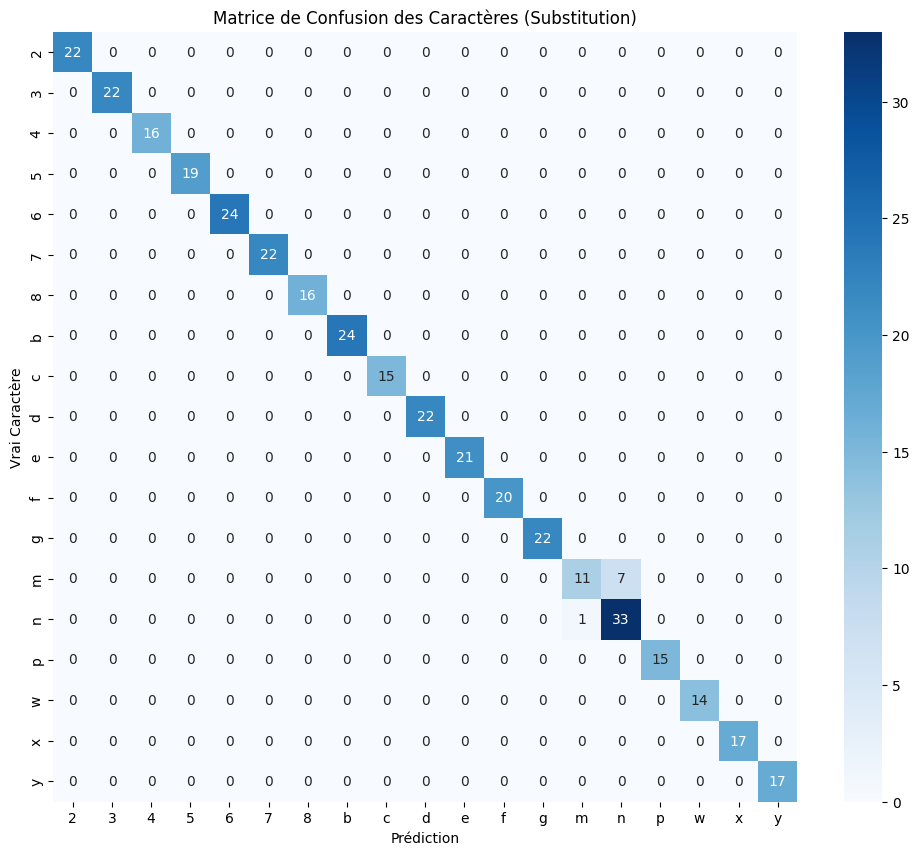

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_char_confusion_matrix(model, loader, mapping):
    model.eval()
    all_targets_chars = []
    all_preds_chars = []
    
    # On récupère toutes les lettres (excluant le blank 0)
    vocab = [mapping[i] for i in sorted(mapping.keys()) if i != 0]
    
    with torch.no_grad():
        for data in loader:
            images = data["images"].to(DEVICE)
            targets = data["targets"]
            
            preds, _ = model(images)
            decoded_preds = decode_predictions(preds, mapping)
            
            for p, t in zip(decoded_preds, targets):
                target_text = "".join([mapping[i.item()] for i in t if i.item() != 0])
                
                # On ne compare que si les longueurs sont identiques pour la matrice de confusion simple
                if len(p) == len(target_text):
                    all_targets_chars.extend(list(target_text))
                    all_preds_chars.extend(list(p))

    # Création de la matrice
    cm = confusion_matrix(all_targets_chars, all_preds_chars, labels=vocab)
    df_cm = pd.DataFrame(cm, index=vocab, columns=vocab)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prédiction')
    plt.ylabel('Vrai Caractère')
    plt.title('Matrice de Confusion des Caractères (Substitution)')
    plt.show()

plot_char_confusion_matrix(model, test_loader, num_to_char)

Interprétation : La diagonale représente les bonnes prédictions. Les points isolés en dehors de la diagonale indiquent des confusions récurrentes. Si une ligne est très sombre en dehors de la diagonale, c'est que ce caractère est le point faible du modèle

# Analyse des "Pires" Erreurs
Pour comprendre les limites du modèle, nous affichons les images où la distance de Levenshtein (calculée par edit_distance) est la plus élevée. Cela aide à voir si l'erreur vient d'un chevauchement de lettres ou de parasites sur l'image.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6225708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6225708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6225708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6225708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6225708].


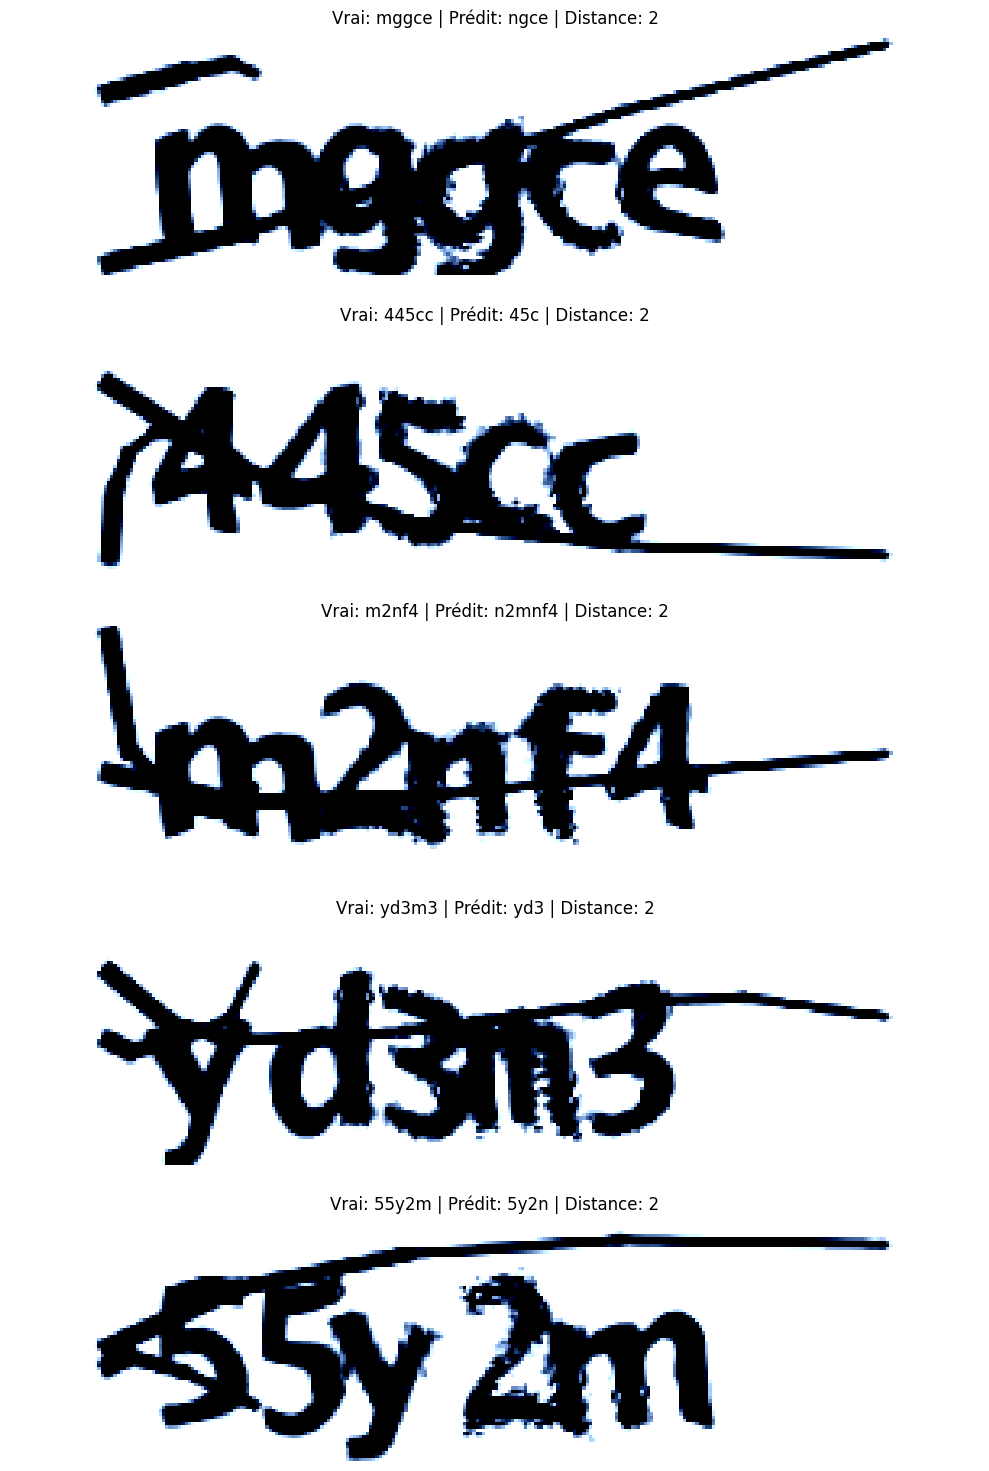

In [24]:
def visualize_worst_errors(model, loader, mapping, n_images=5):
    model.eval()
    errors = []
    
    with torch.no_grad():
        for data in loader:
            images = data["images"].to(DEVICE)
            targets = data["targets"]
            
            preds, _ = model(images)
            decoded_preds = decode_predictions(preds, mapping)
            
            for i in range(len(images)):
                target_text = "".join([mapping[idx.item()] for idx in targets[i] if idx.item() != 0])
                pred_text = decoded_preds[i]
                dist = edit_distance(target_text, pred_text)
                
                if dist > 0:
                    # On stocke l'image (CPU), la prédiction, la cible et la distance
                    errors.append((images[i].cpu(), pred_text, target_text, dist))
    
    # Tri par distance décroissante
    errors.sort(key=lambda x: x[3], reverse=True)
    
    # Affichage
    fig, axes = plt.subplots(n_images, 1, figsize=(10, n_images * 3))
    for i in range(min(n_images, len(errors))):
        img, pred, target, dist = errors[i]
        # On remet l'image au format (H, W, C) et on dé-normalise si besoin
        img = img.permute(1, 2, 0).numpy()
        
        axes[i].imshow(img)
        axes[i].set_title(f"Vrai: {target} | Prédit: {pred} | Distance: {dist}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

visualize_worst_errors(model, test_loader, num_to_char)

In [ ]:
# Utilisation de num_to_char qui est ton dictionnaire {index: caractere}
acc, cer = calculate_metrics(model, test_loader, num_to_char)

print(f"🎯 Accuracy (mots parfaits) : {acc:.2f}%")
print(f"📏 CER (taux d'erreur de caractères) : {cer:.2f}%")

🎯 Accuracy (mots parfaits) : 65.38%
📏 CER (taux d'erreur de caractères) : 7.88%


# Sauvegarde du Modèle et des Métadonnées

In [17]:
import joblib

# 1. Définition des noms de fichiers
MODEL_PATH = "captcha_model.pth"
MAPPING_PATH = "mapping.joblib"

# 2. Sauvegarde des poids du modèle
# On sauvegarde le 'state_dict' qui contient tous les paramètres ajustés par l'optimiseur
torch.save(model.state_dict(), MODEL_PATH)

# 3. Sauvegarde du dictionnaire de correspondance
# On enregistre le vocabulaire pour garantir que les futurs décodages soient identiques
metadata = {
    "char_to_num": char_to_num,
    "num_to_char": num_to_char,
    "vocab": vocab
}
joblib.dump(metadata, MAPPING_PATH)

print(f"✅ Modèle sauvegardé dans : {MODEL_PATH}")
print(f"✅ Métadonnées sauvegardées dans : {MAPPING_PATH}")

✅ Modèle sauvegardé dans : captcha_model.pth
✅ Métadonnées sauvegardées dans : mapping.joblib


# Inférence et Résolution "Clé en Main"

In [18]:
import joblib
import torch
from PIL import Image
import numpy as np
import albumentations
from typing import Dict, List, Any

# 1. Rechargement des métadonnées et du dictionnaire [cite: 4]
metadata = joblib.load("mapping.joblib")
char_to_num: Dict[str, int] = metadata["char_to_num"]
num_to_char: Dict[int, str] = metadata["num_to_char"]
vocab: List[str] = metadata["vocab"]

# 2. Reconstruction et chargement du modèle [cite: 3]
# On recrée l'architecture et on injecte les poids appris
inference_model = CaptchaModel(num_chars=len(vocab))
inference_model.load_state_dict(torch.load("captcha_model.pth", map_location=DEVICE))
inference_model.to(DEVICE)
inference_model.eval() # Très important : mode lecture seule

def solve_captcha(image_path: str) -> str:
    """
    Prend le chemin d'une image, applique le prétraitement et retourne le texte.
    
    Args:
        image_path: Le chemin local vers l'image du CAPTCHA.
        
    Returns:
        Le texte prédit par le modèle.
    """
    # Prétraitement identique au dataset d'entraînement [cite: 2, 6]
    image = Image.open(image_path).convert("RGB")
    image = image.resize((300, 75), resample=Image.BILINEAR)
    image_array = np.array(image)
    
    # Normalisation standard [cite: 6]
    aug = albumentations.Compose([
        albumentations.Normalize(
            mean=(0.485, 0.456, 0.406), 
            std=(0.229, 0.224, 0.225), 
            always_apply=True
        )
    ])
    image_norm = aug(image=image_array)["image"]
    image_tensor = np.transpose(image_norm, (2, 0, 1)).astype(np.float32)
    image_tensor = torch.tensor(image_tensor, dtype=torch.float).unsqueeze(0).to(DEVICE)
    
    # Inférence (prédiction) [cite: 3]
    with torch.no_grad():
        preds, _ = inference_model(image_tensor)
        
    # Décodage du résultat numérique en texte [cite: 4]
    decoded_text = decode_predictions(preds, num_to_char)[0]
    return decoded_text

print("✅ Moteur de résolution prêt !")

✅ Moteur de résolution prêt !
